# **CIFO Project 25/26**

In this notebook, we'll develop a Genetic Algorithm to generate a minimalist version of *Girl with a Pearl Earring* by Johannes Vermeer.

The goal of this project is to approximate the original painting using a fixed number of geometric shapes, more specifically 100 triangles. Each triangle is defined by its position, shape, and color. Together, these triangles compose a generated image that should become as visually similar as possible to the original image.

This is an optimization problem because we are searching for the best possible combination of triangles among a very large number of possible solutions. To evaluate how good each generated image is, we compare it with the original image pixel by pixel using the **Root Mean Squared Error (RMSE)**. A lower RMSE means that the generated image is closer to the original one.

The final objective is not to reproduce the painting perfectly, but to explore how Genetic Algorithms can be used to solve a visual optimization problem through iterative improvement.

# Imports

In [1]:
# We need to clone the repository to acess the data and the code 
!git clone https://github.com/isasofesteves/CIFO_NovaIMS_25-26.git

Cloning into 'CIFO_NovaIMS_25-26'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 165 (delta 12), reused 0 (delta 0), pack-reused 141 (from 1)
Receiving objects: 100% (165/165), 2.75 MiB | 28.47 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [2]:
pip install pytorch-msssim

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install cupy-cuda12x

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Data Manipulation & Scientific Computing
import numpy as np
import pandas as pd
from scipy import stats

# Visualization & Plotting
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image
import imageio

# System & File Management
import os
import sys
sys.path.insert(0, './CIFO_NovaIMS_25-26/') # Set the path to the cloned repository
from glob import glob
import importlib

# Logic, Structure & Functional Tools
import random
import itertools
import random
from functools import partial
from collections import defaultdict

# Custom Module Imports & Path Configuration
sys.path.append('')


import func_py_optimized_numba
importlib.reload(func_py_optimized_numba)

from func_py_optimized_numba import *

print("Imports OK")

Imports OK


In [5]:
# Set random seeds for reproducibility
random.seed(42)

print ("Random seed set")

Random seed set


# Initial Analysis
First, we will load the target image and display it to understand what is our target:

Image shape: (400, 300, 4)  dtype: float32


(np.float64(-0.5), np.float64(299.5), np.float64(399.5), np.float64(-0.5))

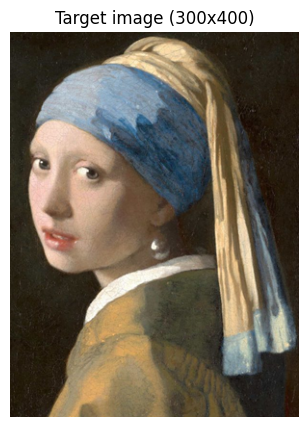

In [6]:

IMAGE_PATH = "/kaggle/working/CIFO_NovaIMS_25-26/girl_pearl_earing.png"
IMG_W, IMG_H    = 300, 400

# Load target image
target = Image.open(IMAGE_PATH).convert("RGBA").resize((IMG_W, IMG_H))
target = np.array(target, dtype=np.float32)  # shape (H, W, 4)

print(f'Image shape: {target.shape}  dtype: {target.dtype}')

# Display target image
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(target.astype(np.uint8))
ax.set_title('Target image (300x400)')
ax.axis('off')


# Model Implementation

## Parameter Set-Up


Before implementing the Genetic Algorithm (GA), we define the fixed environment variables and the search space for hyperparameter tuning.

1. **Fixed Constants**

These parameters remain constant across all experiments to ensure a baseline for comparison.

| Parameter | Value | Description |
| :--- | :--- | :--- |
| **NUM_TRIANGLES** | 100 | Number of triangles per individual. |
| **NUM_GENERATIONS** | 5,000 | Maximum number of generations per run. |
| **STAGNATION_LIMIT** | 200 | Generations to wait for improvement before early stopping. |
| **SAVE_EVERY** | 100 | Frequency (in generations) to save image progress. |

2. **Hyperparameter Grid Search**

We use a grid search approach to find the optimal configuration for the evolution process.

- POP_SIZE: [30, 50, 100, 150, 200] — Total individuals per generation.

- TOURNAMENT_K: [2, 3, 5, 7] — Pressure for selection.

- ELITISM_COUNT: [1, 2, 5] — Number of top performers preserved.

- MUTATION_RATE: [0.01, 0.03, 0.05, 0.10, 0.15] — Probability of random changes.

- CROSSOVER_RATE: [0.5, 0.7, 0.9] — Probability of offspring inheriting from two parents.

>The stagnation limit was treated as a stopping criterion instead of a main parameter.
>Therefore, it will be tuned (if needed) after selecting the main parameters, by comparing the final RMSE and execution time.

In [14]:
NUM_TRIANGLES   = 100               # number of triangles per individual defined fixed 100
SAVE_EVERY      = 100               # save image every N generations
NUM_GENERATIONS = 5000              # nr. generations
STAGNATION_LIMIT = 200              # limit for stagnation detection, treated as a stopping criterion

## Main Loop for the Genetic Algorithm



Now, we will implement the genetic algorithm:

In [7]:
def genetic_algorithm(
    initial_population,
    max_generations,
    selection_algorithm,
    xo_method,
    mut_method,
    target_array,
    tournament_k=5,
    maximization=False,
    xo_prob=0.9,
    mut_prob=0.2,
    elitism=True,
    elitism_count=1,
    verbose=False,
    niche_radius=100.0,
):
    """
    Executes a genetic algorithm to optimize a population of solutions.

    Args:
        initial_population (list[Solution]): The starting population of solutions.
        max_generations (int): The maximum number of generations to evolve.
        selection_algorithm (Callable): Function used for selecting individuals.
        xo_method (Callable): Function used for crossover between two individuals.
        mut_method (Callable): Function used for mutating an individual.
        edge_prob_flat (np.ndarray): Flattened array of edge probabilities.
        target_array (np.ndarray): The target image array.
        maximization (bool, optional): If True, maximizes the fitness function; otherwise, minimizes. Defaults to False.
        xo_prob (float, optional): Probability of applying crossover. Defaults to 0.9.
        mut_prob (float, optional): Probability of applying mutation. Defaults to 0.2.
        elitism (bool, optional): If True, carries the best individual to the next generation. Defaults to True.
        verbose (bool, optional): If True, prints detailed logs for debugging. Defaults to False.
        enable_fitness_sharing (bool, optional): If True, applies fitness sharing. Defaults to False.
        niche_radius (float, optional): The radius for determining niches in fitness sharing. Defaults to 100.0.

    Returns:
        Solution: The best solution found on the last population after evolving for max_gen generations.
        list[float]: The fitness of the best individual over the generations
    """
    population = initial_population
    best_fitness_over_time = []
    enable_fitness_sharing=False
    

    for gen in range(max_generations):

        rendered_cache = render_population_cuda(population)

        # Calculate raw fitness for all individuals
        raw_fitnesses = population_fitness_rmse(rendered_cache, target_array)

        # Calculate initial diversity through phenotypic variance
        if gen == 0:
            initial_var = np.var(raw_fitnesses)
            diversity_threshold = initial_var * 0.1
        
        diversity = np.var(raw_fitnesses)
        enable_fitness_sharing = diversity < diversity_threshold

        # Apply fitness sharing if enabled
        if enable_fitness_sharing:
            niche_counts = calculate_niche_counts(population, niche_radius, rendered=rendered_cache)
            fitnesses = apply_fitness_sharing(raw_fitnesses, niche_counts)
            if verbose and gen % 100 == 0:
                avg_niche = np.mean(niche_counts)
                print(f"Generation {gen}: Avg Niche Count = {avg_niche:.2f}")
        else:
            fitnesses = raw_fitnesses

        best_fitness = max(raw_fitnesses) if maximization else min(raw_fitnesses)
        best_fitness_over_time.append(best_fitness)

        if verbose:
            print(f"Generation {gen}: Best Fitness = {best_fitness}")

        new_population = []

        # Elitism: carry the best individuals to the next generation unchanged
        if elitism and elitism_count > 0:
            elitism_count = min(elitism_count, len(population))
            elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=maximization)[:elitism_count]
            new_population.extend([population[i].copy() for i in elite_indices])

        best_idx = elite_indices[0] if (elitism and elitism_count > 0) else fitnesses.index(best_fitness)
        best_individual = population[best_idx]

        # Save intermediate images every SAVE_EVERY generations
        if gen % SAVE_EVERY == 0:
            img = render(best_individual)
            os.makedirs("output", exist_ok=True)
            plt.imsave(f"output/gen_{gen:04d}.png", img.astype(np.uint8))

        # Generate new population through selection, crossover, and mutation
        while len(new_population) < len(population):
            # Selection
            parent1 = selection_algorithm(population, fitnesses, tournament_k)
            parent2 = selection_algorithm(population, fitnesses, tournament_k)

            # Crossover
            offspring1, offspring2 = xo_method(parent1, parent2, xo_prob)

            # Mutation
            offspring1 = mut_method(offspring1, mut_prob)
            offspring2 = mut_method(offspring2, mut_prob)

            new_population.extend([offspring1, offspring2])

        population = new_population[:len(population)]

        # If no improvement for STAGNATION_LIMIT generations, partially reinitialize worst individuals
        if gen > STAGNATION_LIMIT and best_fitness_over_time[-1] == best_fitness_over_time[-STAGNATION_LIMIT]:
            n_replace = int(0.2 * len(population))
            worst_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:n_replace]
            for i in worst_indices:
                population[i] = random_individual()
            if verbose:
                print(f"Generation {gen}: Partial reinitialization of {n_replace} individuals")

    final_rendered = render_population_cuda(population)

    final_fitnesses = population_fitness_rmse(final_rendered,target_array)
    
    best_solution = population[
        final_fitnesses.index(max(final_fitnesses) if maximization else min(final_fitnesses))
    ].copy()

    return best_solution, best_fitness_over_time

Random combinations of the parameters will be tested using only 500 generations during the first refinement phase, in order to reduce computational cost and identify promising configurations more efficiently:

In [ ]:
# ── Random Search ─────────────────────────────────────────────────────────────
SEARCH_GENERATIONS = 500
N_TRIALS           = 20
RUNS_PER_TRIAL = 30

MUT_WEIGHTS_SPACE = [
    # baseline
    [0.15, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],

    # color_soft + color_hard + alpha
    [0.30, 0.05, 0.05, 0.30, 0.05, 0.15, 0.05, 0.05, 0.00],

    # creep + grow + shrink + translate
    [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.20, 0.20, 0.10],

    # triangle_replacement + color_hard
    [0.05, 0.05, 0.35, 0.25, 0.05, 0.05, 0.05, 0.05, 0.10],

    # color_soft + creep + alpha
    [0.35, 0.30, 0.00, 0.00, 0.00, 0.15, 0.05, 0.05, 0.10],
]


param_space = {
    "POP_SIZE":       [200],
    "TOURNAMENT_K":   [3, 5, 7, 10],
    "MUTATION_RATE":  [0.5, 0.6, 0.7, 0.8, 0.4],
    "CROSSOVER_RATE": [0.1, 0.3, 0.5, 0.7, 0.9],
    "ELITISM_COUNT":  [1, 2, 5, 10],
    "XO_METHOD": [
        uniform_triangle_crossover,
        one_point_crossover,
        two_point_crossover,
    ],
    "MUT_WEIGHTS": MUT_WEIGHTS_SPACE,
}

def sample_params(space):
    return {k: random.choice(v) for k, v in space.items()}

def make_key(p):
    return tuple(
        p[k].__name__ if callable(p[k]) else
        tuple(p[k])   if isinstance(p[k], list) else
        p[k]
        for k in p
    )

sampled = []
seen    = set()
while len(sampled) < N_TRIALS:
    p = sample_params(param_space)
    key = make_key(p)
    if key not in seen:
        seen.add(key)
        sampled.append(p)


final_images   = []
avg_histories  = []
std_histories = []
avg_final_rmse = []
avg_best_rmse = []
all_params     = []


run_history_records = []
avg_history_records = []


for i, params in enumerate(sampled):

    print(f"\n── Trial {i+1}/{N_TRIALS}")

    run_histories = []

    best_overall_dna = None
    best_overall_rmse = float("inf")

    for run in range(RUNS_PER_TRIAL):

        print(f"   Run {run+1}/{RUNS_PER_TRIAL}")

        population = [random_individual() for _ in range(params["POP_SIZE"])]
        mut_method = partial(mixed_mutation, weights=params["MUT_WEIGHTS"])

        best_dna, history = genetic_algorithm(
            initial_population  = population,
            max_generations     = SEARCH_GENERATIONS,
            selection_algorithm = tournament_selection,
            xo_method           = params["XO_METHOD"],
            mut_method          = mut_method,
            target_array        = target,
            tournament_k        = params["TOURNAMENT_K"],
            maximization        = False,
            xo_prob             = params["CROSSOVER_RATE"],
            mut_prob            = params["MUTATION_RATE"],
            elitism             = True,
            elitism_count       = params["ELITISM_COUNT"],
            verbose             = False
        )

        run_histories.append(history)
        run_best_fitness = float(np.min(history))
        run_final_fitness = history[-1]

        
        if run_best_fitness < best_overall_rmse:
            best_overall_rmse = run_best_fitness
            best_overall_dna = best_dna


        # SAVING STATS
        for gen_idx, rmse in enumerate(history):

            run_history_records.append({
                "trial": i + 1,
                "run": run + 1,
                "generation": gen_idx,
                "rmse": float(rmse),
                "run_best_rmse": run_best_fitness,
                "run_final_rmse": run_final_fitness,

                # parameters
                "POP_SIZE": params["POP_SIZE"],
                "TOURNAMENT_K": params["TOURNAMENT_K"],
                "MUTATION_RATE": params["MUTATION_RATE"],
                "CROSSOVER_RATE": params["CROSSOVER_RATE"],
                "ELITISM_COUNT": params["ELITISM_COUNT"],
                "XO_METHOD": params["XO_METHOD"].__name__,

                # convert list to string for csv
                "MUT_WEIGHTS": str(params["MUT_WEIGHTS"])
            })



    run_histories = np.array(run_histories)

    # Average RMSE at each generation 
    avg_history = np.mean(run_histories, axis=0)

    # Std of runs 
    std_history = np.std(run_histories, axis=0)

    for gen_idx, rmse in enumerate(avg_history):

        avg_history_records.append({
            "trial": i + 1,
            "generation": gen_idx,
            "avg_rmse": float(rmse),
            "std_rmse": float(std_history[gen_idx]),

            # params (optional but useful)
            "POP_SIZE": params["POP_SIZE"],
            "TOURNAMENT_K": params["TOURNAMENT_K"],
            "MUTATION_RATE": params["MUTATION_RATE"],
            "CROSSOVER_RATE": params["CROSSOVER_RATE"],
            "ELITISM_COUNT": params["ELITISM_COUNT"],
            "XO_METHOD": params["XO_METHOD"].__name__,
            #"DIVERSITY_THRESHOLD": params["DIVERSITY_THRESHOLD"],
        })


    # Append averaged history trial history lists
    avg_histories.append(avg_history) 
    std_histories.append(std_history)

    avg_final_rmse.append(avg_history[-1])
    avg_best_rmse.append(float(np.min(avg_history)))

    final_images.append(render(best_overall_dna))
    all_params.append(params)

    print(f"Final RMSE: {avg_history[-1]:.4f} | Best RMSE: {float(np.min(avg_history)):.4f} | (Trial {i+1}/{N_TRIALS})")


# Best overall result
best_idx = int(np.argmin(avg_best_rmse))
best_params = all_params[best_idx]

print(f"\nBest combination (trial {best_idx + 1}):")

for k, v in best_params.items():
    print(f"   {k}: {v.__name__ if callable(v) else v}")

print(f"   Best RMSE: {np.min(avg_histories[best_idx]):.4f}")


df_history = pd.DataFrame(run_history_records)
df_history.to_csv("ga_search_history.csv", index=False)

df_avg = pd.DataFrame(avg_history_records)
df_avg.to_csv("ga_avg_histories.csv", index=False)

print("CSV saved")



── Trial 1/20
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
   Run 10/30
   Run 11/30
   Run 12/30
   Run 13/30
   Run 14/30
   Run 15/30
   Run 16/30
   Run 17/30
   Run 18/30
   Run 19/30
   Run 20/30
   Run 21/30
   Run 22/30
   Run 23/30
   Run 24/30
   Run 25/30
   Run 26/30
   Run 27/30
   Run 28/30
   Run 29/30
   Run 30/30
Final RMSE: 28.4195 | Best RMSE: 28.4195 | (Trial 1/20)

── Trial 2/20
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
   Run 10/30
   Run 11/30
   Run 12/30
   Run 13/30
   Run 14/30
   Run 15/30
   Run 16/30
   Run 17/30
   Run 18/30
   Run 19/30
   Run 20/30
   Run 21/30
   Run 22/30
   Run 23/30
   Run 24/30
   Run 25/30
   Run 26/30
   Run 27/30
   Run 28/30
   Run 29/30
   Run 30/30
Final RMSE: 30.6746 | Best RMSE: 30.6746 | (Trial 2/20)

── Trial 3/20
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/

Best combination (trial 19):
   POP_SIZE: 200
   TOURNAMENT_K: 7
   MUTATION_RATE: 0.4
   CROSSOVER_RATE: 0.9
   ELITISM_COUNT: 2
   XO_METHOD: <function uniform_triangle_crossover at 0x7efc63710e00>
   MUT_WEIGHTS: [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.2, 0.2, 0.1]
   Final RMSE: 25.8933


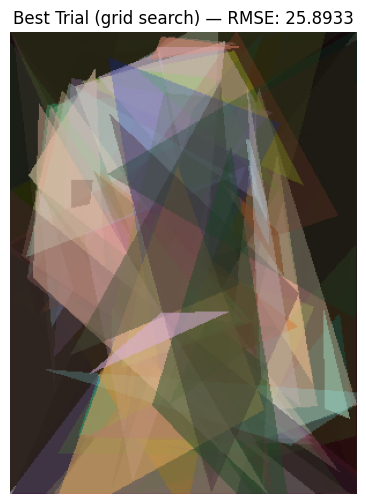

In [ ]:
# Save results of random search
best_trial_index = int(np.argmin(avg_final_rmse))
best_params = all_params[best_trial_index]

print(f"Best combination (trial {best_trial_index+1}):")
for k, v in best_params.items():
    print(f"   {k}: {v}")
print(f"   Final RMSE: {avg_final_rmse[best_trial_index]:.4f}")

# Visualise image of grid search
plt.figure(figsize=(5, 6))
plt.imshow(final_images[best_trial_index].astype(np.uint8))
plt.title(f"Best Trial (grid search) — RMSE: {avg_final_rmse[best_trial_index]:.4f}")
plt.axis("off")
plt.show()

## Comparison of Results

### Comparison of all the trials

Now, statistical tests will be performed to compare the performance of all 20 trials.

**Hypothesis tested**:
- H0: all combinations have similar RMSE distributions.
- H1: at least one combination is different.
-----------------------------------------------------------------------------

First, check if the data is normally distributed using the **Shapiro-Wilk test**:
- H0: The data is normally distributed.
- H1: The data is not normally distributed.

In [4]:
avg_df = pd.read_csv("ga_avg_histories.csv")

avg_df.head()

,trial,generation,avg_rmse,std_rmse,POP_SIZE,TOURNAMENT_K,MUTATION_RATE,CROSSOVER_RATE,ELITISM_COUNT,XO_METHOD
0,1,0,94.454355,2.089692,200,3,0.7,0.3,2,uniform_triangle_crossover
1,1,1,93.018093,2.072422,200,3,0.7,0.3,2,uniform_triangle_crossover
2,1,2,91.241840,2.177822,200,3,0.7,0.3,2,uniform_triangle_crossover
3,1,3,89.039359,2.058581,200,3,0.7,0.3,2,uniform_triangle_crossover
4,1,4,86.922691,1.577629,200,3,0.7,0.3,2,uniform_triangle_crossover


In [5]:
normality_results = {}

for trial, group in avg_df.groupby("trial"):
    stat, p_value = stats.shapiro(group["avg_rmse"])
    normality_results[trial] = (stat, p_value)

print("Shapiro-Wilk Normality Test Results:")
for trial, (stat, p_value) in normality_results.items():
    if p_value >= 0.05:
        print(f"Trial {trial}: Data is normally distributed (p={p_value:.4f})")
    else:
        print(f"Trial {trial}: Data is NOT normally distributed (p={p_value:.4f})")

Shapiro-Wilk Normality Test Results:
Trial 1: Data is NOT normally distributed (p=0.0000)
Trial 2: Data is NOT normally distributed (p=0.0000)
Trial 3: Data is NOT normally distributed (p=0.0000)
Trial 4: Data is NOT normally distributed (p=0.0000)
Trial 5: Data is NOT normally distributed (p=0.0000)
Trial 6: Data is NOT normally distributed (p=0.0000)
Trial 7: Data is NOT normally distributed (p=0.0000)
Trial 8: Data is NOT normally distributed (p=0.0000)
Trial 9: Data is NOT normally distributed (p=0.0000)
Trial 10: Data is NOT normally distributed (p=0.0000)
Trial 11: Data is NOT normally distributed (p=0.0000)
Trial 12: Data is NOT normally distributed (p=0.0000)
Trial 13: Data is NOT normally distributed (p=0.0000)
Trial 14: Data is NOT normally distributed (p=0.0000)
Trial 15: Data is NOT normally distributed (p=0.0000)
Trial 16: Data is NOT normally distributed (p=0.0000)
Trial 17: Data is NOT normally distributed (p=0.0000)
Trial 18: Data is NOT normally distributed (p=0.0000)


We will use a non-parametric **Kruskal-Wallis test**, because the data is not normally distributed. This test does not assume normality and is suitable for comparing more than two independent groups.

In [6]:
groups = [group["avg_rmse"].values for _, group in avg_df.groupby("trial")]

stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis Test: p={p_value:.4f}")
if p_value < 0.05:
    print("There are significant differences between the groups.")
else:
    print("No significant differences found between the groups.")

Kruskal-Wallis Test: p=0.0000
There are significant differences between the groups.


The groups are significantly different, so we will perform more tests to identify which specific groups differ from each other:
- Man Whitney U test (pairwise comparisons between groups).
- Holm correction for multiple comparisons.

Holm adjusted p_value:
- Order the p-values from smallest to largest.
- Count the number of comparisons (m).
- Multiply each p-value by (m - rank + 1) to get the adjusted p-value.
- Compare each adjusted p-value to the significance level (e.g., 0.05).

*Apply the consistency check*: an adjusted p-value must never be smaller than the previous one. If an adjusted p-value is smaller than the previous one, set it equal to the previous one. This ensures that the adjusted p-values are non-decreasing as you move through the ordered list.

*Maximum limit*: if any adjusted p-value exceeds 1.0, it should be set to 1.0, since p-values cannot be greater than 1.0.

In [8]:
# Test pairs of combinations using Mann-Whitney U test --> 20 choose 2 = 190 pairs
pairwise_results = []

trial_numbers = sorted(avg_df["trial"].unique()) # sorted to ensure consistent order

for i, j in itertools.combinations(trial_numbers, 2):
    group1 = avg_df[avg_df["trial"] == i]["avg_rmse"]
    group2 = avg_df[avg_df["trial"] == j]["avg_rmse"]
    stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    pairwise_results.append({
    "combination_1": i,
    "combination_2": j,
    "u_statistic": stat,
    "p_value": p_value
})

pairwise_df = pd.DataFrame(pairwise_results)

reject, adjusted_p_values, _, _ = multipletests(pairwise_df["p_value"], method='holm')

pairwise_df["adjusted_p_value"] = adjusted_p_values
number_dif = 0

print(f" Significant pairs after Holm correction (adjusted p < 0.05): ")
for _, row in pairwise_df.iterrows():
    if row["adjusted_p_value"] < 0.05:
        print(f"   Trial {int(row['combination_1'])} vs Trial {int(row['combination_2'])} are significantly different (adjusted p={row['adjusted_p_value']:.4f})")
        number_dif += 1
print(f"\nTotal significant pairs: {number_dif} out of {len(pairwise_df)}")


 Significant pairs after Holm correction (adjusted p < 0.05): 
   Trial 1 vs Trial 2 are significantly different (adjusted p=0.0001)
   Trial 1 vs Trial 3 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 4 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 5 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 8 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 10 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 11 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 15 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 18 are significantly different (adjusted p=0.0000)
   Trial 1 vs Trial 19 are significantly different (adjusted p=0.0000)
   Trial 2 vs Trial 3 are significantly different (adjusted p=0.0000)
   Trial 2 vs Trial 6 are significantly different (adjusted p=0.0000)
   Trial 2 vs Trial 8 are significantly different (adjusted p=0.0000)
   Trial 2 vs Trial 9 

### Comparison of the best combination per crossover method

Comparing the best trial for each cross-over method:

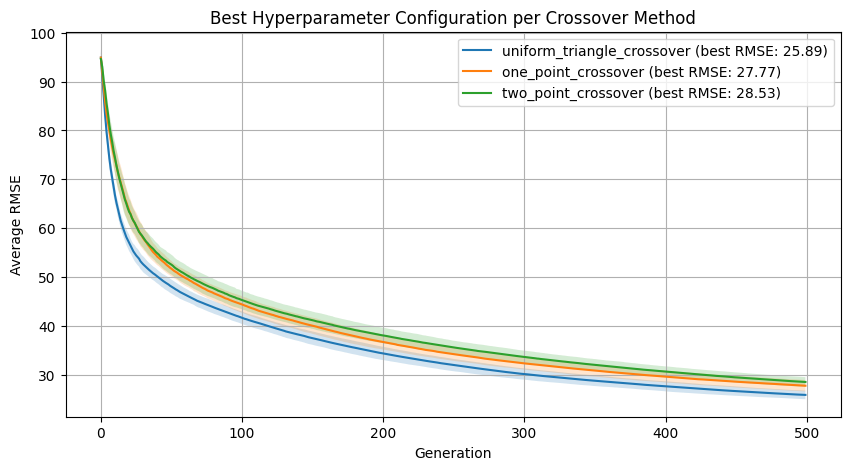

In [ ]:
# ── Group best history by crossover ────────────────────────────────────
best_by_xo = defaultdict(lambda: {"rmse": float("inf"), "params": None, "history": None})

for params, fitness, history in zip(all_params, avg_final_rmse, avg_histories):
    xo_name = params["XO_METHOD"].__name__
    if fitness < best_by_xo[xo_name]["rmse"]:
        best_by_xo[xo_name] = {
            "rmse":    fitness,
            "params":  params,
            "history": history,
        }

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))

for xo_name, data in best_by_xo.items():

    generations = np.arange(len(data["history"]))

    plt.plot(
        generations,
        data["history"],
        label=f"{xo_name} (best RMSE: {data['rmse']:.2f})"
    )

    idx = all_params.index(data["params"])
    std = std_histories[idx]

    plt.fill_between(
        generations,
        data["history"] - std,
        data["history"] + std,
        alpha=0.2
    )

plt.xlabel("Generation")
plt.ylabel("Average RMSE")
plt.title("Best Hyperparameter Configuration per Crossover Method")
plt.legend()
plt.grid(True)
plt.show()

Using the best trial of each crossover method would not provide a fair comparison, as several parameters differ simultaneously. Therefore, the best overall parameter configuration is kept fixed and only the crossover operator is changed to evaluate its effect on performance.

In [17]:
# ── Crossover Methods Comparison ─────────────────────────────────────────────────────────────
SEARCH_GENERATIONS = 500
RUNS_PER_TRIAL = 30

param_space = [
    {
        "POP_SIZE": 200,
        "TOURNAMENT_K": 7,
        "MUTATION_RATE": 0.4,
        "CROSSOVER_RATE": 0.9,
        "ELITISM_COUNT": 2,
        "XO_METHOD": uniform_triangle_crossover,
        "MUT_WEIGHTS": [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.2, 0.2, 0.1],
    },
    {
        "POP_SIZE": 200,
        "TOURNAMENT_K": 7,
        "MUTATION_RATE": 0.4,
        "CROSSOVER_RATE": 0.9,
        "ELITISM_COUNT": 2,
        "XO_METHOD": one_point_crossover,
        "MUT_WEIGHTS": [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.2, 0.2, 0.1],
    },
    {
        "POP_SIZE": 200,
        "TOURNAMENT_K": 7,
        "MUTATION_RATE": 0.4,
        "CROSSOVER_RATE": 0.9,
        "ELITISM_COUNT": 2,
        "XO_METHOD": two_point_crossover,
        "MUT_WEIGHTS": [0.05, 0.25, 0.05, 0.05, 0.05, 0.05, 0.2, 0.2, 0.1],
    },
]


final_images   = []
avg_histories  = []
std_histories = []
avg_final_rmse = []
avg_best_rmse = []
all_params     = []


run_history_records = []
avg_history_records = []


for i, params in enumerate(param_space):

    print(f"\n── Trial: {params["XO_METHOD"]}")

    run_histories = []

    best_overall_dna = None
    best_overall_rmse = float("inf")

    for run in range(RUNS_PER_TRIAL):

        print(f"   Run {run+1}/{RUNS_PER_TRIAL}")

        population = [random_individual() for _ in range(params["POP_SIZE"])]
        mut_method = partial(mixed_mutation, weights=params["MUT_WEIGHTS"])

        best_dna, history = genetic_algorithm(
            initial_population  = population,
            max_generations     = SEARCH_GENERATIONS,
            selection_algorithm = tournament_selection,
            xo_method           = params["XO_METHOD"],
            mut_method          = mut_method,
            target_array        = target,
            tournament_k        = params["TOURNAMENT_K"],
            maximization        = False,
            xo_prob             = params["CROSSOVER_RATE"],
            mut_prob            = params["MUTATION_RATE"],
            elitism             = True,
            elitism_count       = params["ELITISM_COUNT"],
            verbose             = False
        )

        run_histories.append(history)
        run_best_fitness = float(np.min(history))
        run_final_fitness = history[-1]

        
        if run_best_fitness < best_overall_rmse:
            best_overall_rmse = run_best_fitness
            best_overall_dna = best_dna


        # SAVING STATS
        for gen_idx, rmse in enumerate(history):

            run_history_records.append({
                "trial": i + 1,
                "run": run + 1,
                "generation": gen_idx,
                "rmse": float(rmse),
                "run_best_rmse": run_best_fitness,
                "run_final_rmse": run_final_fitness,

                # parameters
                "POP_SIZE": params["POP_SIZE"],
                "TOURNAMENT_K": params["TOURNAMENT_K"],
                "MUTATION_RATE": params["MUTATION_RATE"],
                "CROSSOVER_RATE": params["CROSSOVER_RATE"],
                "ELITISM_COUNT": params["ELITISM_COUNT"],
                "XO_METHOD": params["XO_METHOD"].__name__,

                # convert list to string for csv
                "MUT_WEIGHTS": str(params["MUT_WEIGHTS"])
            })



    run_histories = np.array(run_histories)

    # Average RMSE at each generation 
    avg_history = np.mean(run_histories, axis=0)

    # Std of runs 
    std_history = np.std(run_histories, axis=0)

    for gen_idx, rmse in enumerate(avg_history):

        avg_history_records.append({
            "trial": i + 1,
            "generation": gen_idx,
            "avg_rmse": float(rmse),
            "std_rmse": float(std_history[gen_idx]),

            # params (optional but useful)
            "POP_SIZE": params["POP_SIZE"],
            "TOURNAMENT_K": params["TOURNAMENT_K"],
            "MUTATION_RATE": params["MUTATION_RATE"],
            "CROSSOVER_RATE": params["CROSSOVER_RATE"],
            "ELITISM_COUNT": params["ELITISM_COUNT"],
            "XO_METHOD": params["XO_METHOD"].__name__,
        })


    # Append averaged history trial history lists
    avg_histories.append(avg_history) 
    std_histories.append(std_history)

    avg_final_rmse.append(avg_history[-1])
    avg_best_rmse.append(float(np.min(avg_history)))

    final_images.append(render(best_overall_dna))
    all_params.append(params)

    print(f"Final RMSE: {avg_history[-1]:.4f} | Best RMSE: {float(np.min(avg_history)):.4f} | (Trial : {params["XO_METHOD"]})")


df_history = pd.DataFrame(run_history_records)
df_history.to_csv("xo_search_history.csv", index=False)

df_avg = pd.DataFrame(avg_history_records)
df_avg.to_csv("xo_avg_histories.csv", index=False)

print("CSV saved")



── Trial: <function uniform_triangle_crossover at 0x7d5eb834d800>
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
   Run 10/30
   Run 11/30
   Run 12/30
   Run 13/30
   Run 14/30
   Run 15/30
   Run 16/30
   Run 17/30
   Run 18/30
   Run 19/30
   Run 20/30
   Run 21/30
   Run 22/30
   Run 23/30
   Run 24/30
   Run 25/30
   Run 26/30
   Run 27/30
   Run 28/30
   Run 29/30
   Run 30/30
Final RMSE: 25.8199 | Best RMSE: 25.8199 | (Trial : <function uniform_triangle_crossover at 0x7d5eb834d800>)

── Trial: <function one_point_crossover at 0x7d5eb834d8a0>
   Run 1/30
   Run 2/30
   Run 3/30
   Run 4/30
   Run 5/30
   Run 6/30
   Run 7/30
   Run 8/30
   Run 9/30
   Run 10/30
   Run 11/30
   Run 12/30
   Run 13/30
   Run 14/30
   Run 15/30
   Run 16/30
   Run 17/30
   Run 18/30
   Run 19/30
   Run 20/30
   Run 21/30
   Run 22/30
   Run 23/30
   Run 24/30
   Run 25/30
   Run 26/30
   Run 27/30
   Run 28/30
   Run 29/30
   Run 30/30
Fi

In [ ]:
avg_xo = pd.read_csv("xo_avg_histories.csv")

final_avg_by_trial =(avg_xo.sort_values(["trial", "generation"]).groupby(
    "trial", as_index=False).tail(1).copy())

print("Results by crossover method:")
for _, row in final_avg_by_trial.iterrows():
    print(f"   XO_METHOD: {row['XO_METHOD']} | Final RMSE: {row['avg_rmse']:.4f}")

#Normality Tests--------------------------------------------------------------
normality_results = {}

for trial, group in avg_xo.groupby("trial"):
    stat, p_value = stats.shapiro(group["avg_rmse"])
    normality_results[trial] = (stat, p_value)

print("\nShapiro-Wilk Normality Test Results:")
for trial, (stat, p_value) in normality_results.items():
    if p_value >= 0.05:
        print(f"Trial {trial}: Data is normally distributed (p={p_value:.4f})")
    else:
        print(f"Trial {trial}: Data is NOT normally distributed (p={p_value:.4f})")

#Pair-wise Mann–Whitney U tests -----------------------------------------------
pairwise_results = []

trial_numbers = sorted(avg_xo["trial"].unique())

# Map each trial to its crossover method
trial_to_xo = (
    avg_xo[["trial", "XO_METHOD"]]
    .drop_duplicates()
    .set_index("trial")["XO_METHOD"]
    .to_dict()
)


for i, j in itertools.combinations(trial_numbers, 2):
    group1 = avg_xo[avg_xo["trial"] == i]["avg_rmse"]
    group2 = avg_xo[avg_xo["trial"] == j]["avg_rmse"]
    stat, p_value = stats.mannwhitneyu(group1, group2, alternative="two-sided")

    xo_i = trial_to_xo[i]
    xo_j = trial_to_xo[j]

    pairwise_results.append({
        "combination_1": xo_i,
        "combination_2": xo_j,
        "u_statistic": stat,
        "p_value": p_value
    })

pairwise_df_xo = pd.DataFrame(pairwise_results)

print (f"\nPairwise Mann-Whitney U Test Results by Crossover Method:")
for _, row in pairwise_df_xo.iterrows():
    if row["p_value"] < 0.05:
        print(f"   {row['combination_1']} vs {row['combination_2']} are significantly different (p={row['p_value']:.4f})")
    else:
        print(f"   {row['combination_1']} vs {row['combination_2']} are NOT significantly different (p={row['p_value']:.4f})")

Results by crossover method:
   XO_METHOD: uniform_triangle_crossover | Final RMSE: 25.8199
   XO_METHOD: one_point_crossover | Final RMSE: 28.7998
   XO_METHOD: two_point_crossover | Final RMSE: 27.9668

Shapiro-Wilk Normality Test Results:
Trial 1: Data is NOT normally distributed (p=0.0000)
Trial 2: Data is NOT normally distributed (p=0.0000)
Trial 3: Data is NOT normally distributed (p=0.0000)

Pairwise Mann-Whitney U Test Results:

Pairwise Mann-Whitney U Test Results by Crossover Method:
   uniform_triangle_crossover vs one_point_crossover are significantly different (p=0.0000)
   uniform_triangle_crossover vs two_point_crossover are significantly different (p=0.0000)
   one_point_crossover vs two_point_crossover are significantly different (p=0.0279)


## Run full GA

In [ ]:
# ── Run GA with best parameters ────────────────────────────
print("\nRunning full GA with best parameters...")

population = [random_individual() for _ in range(best_params["POP_SIZE"])]

best_dna_final, history_final = genetic_algorithm(
    initial_population  = population,
    max_generations     = NUM_GENERATIONS,
    selection_algorithm = tournament_selection,
    xo_method           = uniform_triangle_crossover,
    mut_method          = mixed_mutation,
    target_array        = target,
    tournament_k        = best_params["TOURNAMENT_K"],
    maximization        = False,
    xo_prob             = best_params["CROSSOVER_RATE"],
    mut_prob            = best_params["MUTATION_RATE"],
    elitism             = True,
    elitism_count       = best_params["ELITISM_COUNT"],
    verbose             = True
)


Running full GA with best parameters...
Generation 0: Best Fitness = 93.10980224609375
Generation 1: Best Fitness = 88.75216674804688
Generation 2: Best Fitness = 83.81958770751953
Generation 3: Best Fitness = 79.92919921875
Generation 4: Best Fitness = 77.43983459472656
Generation 5: Best Fitness = 74.55724334716797
Generation 6: Best Fitness = 71.57311248779297
Generation 7: Best Fitness = 70.716064453125
Generation 8: Best Fitness = 68.0563735961914
Generation 9: Best Fitness = 67.01043701171875
Generation 10: Best Fitness = 64.69469451904297
Generation 11: Best Fitness = 63.78742980957031
Generation 12: Best Fitness = 62.93510055541992
Generation 13: Best Fitness = 61.672786712646484
Generation 14: Best Fitness = 60.00577926635742
Generation 15: Best Fitness = 59.55996322631836
Generation 16: Best Fitness = 59.02130126953125
Generation 17: Best Fitness = 57.64596176147461
Generation 18: Best Fitness = 57.04172897338867
Generation 19: Best Fitness = 56.40507888793945
Generation 20:

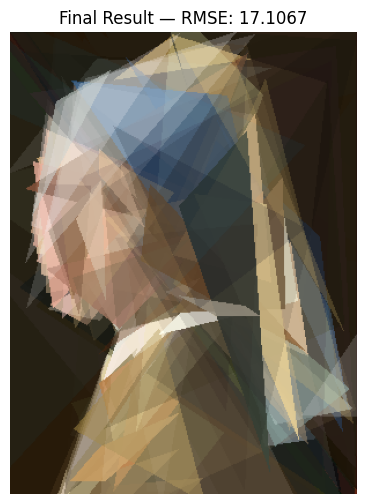

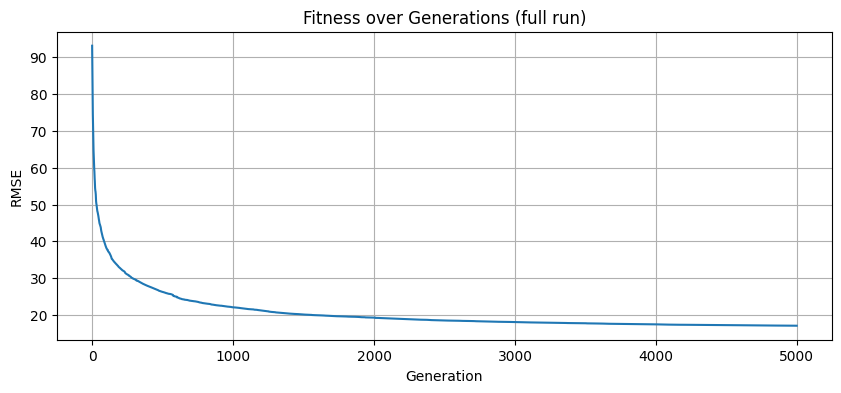

/tmp/ipykernel_24/1456170957.py:20: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in sorted(glob("output/*.png"))]


Saved evolution.gif


In [14]:
# ── Final Results ─────────────────────────────────────────────────────────

# Final image
plt.figure(figsize=(5, 6))
plt.imshow(render(best_dna_final).astype(np.uint8))
plt.title(f"Final Result — RMSE: {history_final[-1]:.4f}")
plt.axis("off")
plt.show()

# Fitness over generations
plt.figure(figsize=(10, 4))
plt.plot(history_final)
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.title("Fitness over Generations (full run)")
plt.grid(True)
plt.show()

# GIF
frames = [imageio.imread(f) for f in sorted(glob("output/*.png"))]
imageio.mimsave("evolution.gif", frames, fps=10)
print("Saved evolution.gif")